# Which halos drive the baryonic suppression of the matter power spectrum?

### A field-level, fixed-halo decomposition across the CAMELS feedback prior

**Abstract.** Baryonic feedback suppresses the small-scale matter power spectrum
$S(k)\equiv P_{\rm hydro}(k)/P_{\rm DMO}(k)$ — the leading astrophysical systematic
for Stage-IV weak lensing. It is well established that group-scale halos dominate
the *mean* suppression. We ask a different, decision-relevant question: across the
*uncertain* feedback parameter space, **which halos drive the _variance_ of
$S(k)$** — and is that variance set by halo mass alone, or by gas content *at fixed
mass*? We answer it with a capability unique to a field-level emulator (BIND2):
holding a single set of 1111 dark-matter halos fixed (fixed cosmology, initial
conditions, and generator noise), we re-paint their baryons under a 256-point Sobol
design in 30 feedback parameters, paste them back into the box, and **mask halo
subsets** to measure their partial contribution to $S(k)$ — all without running a
single additional hydrodynamic simulation. We find that the variance of the
weak-lensing-scale suppression is carried roughly half by the group decade
$[10^{13},10^{13.5}]\,M_\odot/h$, and — at fixed mass — predominantly by the
*gas-rich* tail. This identifies the observable (the gas content of groups) whose
measurement would most tightly constrain the weak-lensing baryonic prior.

*Companion to `scaling_relations.ipynb` (the per-halo scaling relations + the
controlled feedback experiment that motivates this decomposition).*


## 1. The scientific question

Modelling baryonic feedback is the dominant theoretical systematic for cosmic-shear
cosmology. The community summarises it through the **matter-power suppression**
$$S(k) = \frac{P_{\rm hydro}(k)}{P_{\rm DMO}(k)},$$
which drops to $\sim\!0.8$ at $k\sim10\,h\,{\rm Mpc}^{-1}$ in current hydro models,
with a model-to-model scatter that is itself a large part of the WL error budget.

Two things are known and one is not:

- **Known:** the *mean* suppression at these scales is dominated by group-/low-mass-
  cluster-scale halos ($10^{13}$–$10^{14}\,M_\odot/h$), through feedback-driven gas
  expulsion (van Daalen+2020; and the "beyond-$r_{\rm vir}$" redistribution of
  Miller+2024).
- **Known:** at fixed mass, halos split into gas-rich and gas-poor populations whose
  baryon content responds strongly to feedback (see `scaling_relations.ipynb`).
- **Open — and what we answer here:** across the *prior* on feedback, **which halo
  population carries the _uncertainty_ in $S(k)$?** Variance, not the mean, is what a
  survey must pin down. If, say, half of $\mathrm{Var}_\theta[S(k)]$ comes from the
  gas content of $[10^{13},10^{13.5}]$ groups, then an X-ray/SZ measurement of group
  gas fractions is the most direct lever on the WL baryonic prior.

No prior study has decomposed $S(k)$ this way at scale: it requires a model that
generates the *gas field itself* for *many* parameter points while *holding the
halos fixed* — exactly what a field-level emulator provides.


In [1]:
# ── setup ────────────────────────────────────────────────────────────────
from __future__ import annotations
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "notebook"])
except Exception:
    pass
mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200,
                     "savefig.bbox": "tight", "axes.grid": False})

CACHE = Path("analysis_physics_cache")
FIG = Path("paper_figures"); FIG.mkdir(exist_ok=True)
SOBOL = Path("/mnt/home/mlee1/ceph/sobol_ss_cv")

# --- caches: prefer the full 256-design run, fall back to the 32-design prototype
_full = CACHE / "partial_supp_sobol.npz"
PART = _full if _full.exists() else CACHE / "partial_supp_proto.npz"
IS_PROTO = "proto" in PART.name
z = np.load(PART, allow_pickle=True)
dids   = z["design_ids"]
k      = z["k_box"]
S_full = z["S_full"]                 # (D, nk)  all halos painted
S_sub  = z["S_sub"]                  # (D, 9, nk) subset-only ("first in")
S_loo  = z["S_loo"]                  # (D, 9, nk) leave-one-out ("last in")
n_sub  = z["n_sub"]                  # (D, 9) halo counts
mass_labels = [str(s) for s in z["mass_labels"]]
gas_labels  = [str(s) for s in z["gas_labels"]]
D = len(dids)

box = np.load(CACHE / "box_supp_sobol.npz")     # full 256-design box S(k) (pre-computed)
k_box, S_true_box, S_truth = box["k_box"], box["S_true"], box["S_truth"]

cube  = np.load(SOBOL / "cube.npz", allow_pickle=True)
desn  = np.load(SOBOL / "design.npz", allow_pickle=True)
astro = [str(s) for s in cube["astro_names"]]
Dn    = cube["design_norm"]                      # (256, 30) all designs
logM_all = np.log10(np.asarray(cube["M200"], float))

# representative design nearest the CV fiducial in standardised astro-param space
# (used only to ILLUSTRATE the subset definition in Fig 3)
_fa = np.asarray(desn["fiducial"])[np.asarray(cube["astro_idx"])]
_phys = np.asarray(cube["design_astro_phys"]); _zc = (_phys - _phys.mean(0)) / _phys.std(0)
near = int(np.argmin(((_zc - (_fa - _phys.mean(0)) / _phys.std(0)) ** 2).sum(1)))

def kidx(kt, kk=k):
    return int(np.argmin(np.abs(kk - kt)))

# ---- estimators (self-contained; see Methods §2.3-2.4) ----------------------
def shapley_contrib(ik):
    """2-bracket Shapley contribution c_s and full modification dS_full at bin ik."""
    only = S_sub[:, :, ik] - 1.0                 # subset painted alone (over-counts)
    loo  = S_full[:, ik][:, None] - S_loo[:, :, ik]   # removal effect (under-counts)
    return 0.5 * (only + loo), S_full[:, ik] - 1.0, only, loo

def cov_share(c, dSf):
    """Variance partition share_s = Cov(c_s, dS_full)/Var(dS_full) (raw; sums ~1)."""
    cov = np.array([np.cov(c[:, s], dSf)[0, 1] for s in range(c.shape[1])])
    return cov / dSf.var()

def boot_shares(ik, B=2000, seed=0):
    """Bootstrap over designs -> (B, 9) variance shares."""
    rng = np.random.default_rng(seed)
    c, dSf, *_ = shapley_contrib(ik)
    out = np.empty((B, 9))
    for b in range(B):
        idx = rng.integers(0, D, D)
        out[b] = cov_share(c[idx], dSf[idx])
    return out

def src_betas(X01, y):
    """Standardised OLS betas of y on the design X01 (Sobol -> near-orthogonal)."""
    X = (X01 - X01.mean(0)) / X01.std(0)
    yy = (y - y.mean()) / (y.std() + 1e-12)
    b, *_ = np.linalg.lstsq(np.column_stack([X, np.ones(len(yy))]), yy, rcond=None)
    return b[:X.shape[1]]

def uni_corr(X01, y):
    """Univariate standardised slope == corr for an orthogonal design (robust, small n)."""
    return np.array([np.corrcoef(X01[:, p], y)[0, 1] for p in range(X01.shape[1])])

# feedback-STRENGTH axis: SRC projection of the (1 - S_box) outcome onto the 30-D
# design, fit on all 256 box designs (robust), so higher score = stronger feedback.
_betas_box = src_betas(Dn, 1.0 - S_true_box[:, kidx(10.0, k_box)])
def feedback_score(design_ids):
    Xs = (Dn[design_ids] - Dn.mean(0)) / Dn.std(0)
    return Xs @ _betas_box

MASS_C = ["#1b9e77", "#d95f02", "#7570b3"]       # per mass-decade colour
GAS_C  = {"gas-poor": "#4575b4", "gas-mid": "#999999", "gas-rich": "#d73027"}

print("=" * 64)
print(f"partial-S(k) cache : {PART.name}   ({D} designs, 9 subsets, {len(k)} k-bins)")
if IS_PROTO:
    print("MODE: PROTOTYPE (thin slice) — numbers indicative, CIs wide.")
    print("Re-run after the full campaign for paper numbers:")
    print("  N_CHUNKS=16 sbatch --array=0-15 run_partial_supp.sh")
    print("  python tools/partial_supp_sobol.py --reduce   # writes partial_supp_sobol.npz")
else:
    print("MODE: FULL 256-design campaign.")
print("=" * 64)


partial-S(k) cache : partial_supp_sobol.npz   (256 designs, 9 subsets, 724 k-bins)
MODE: FULL 256-design campaign.


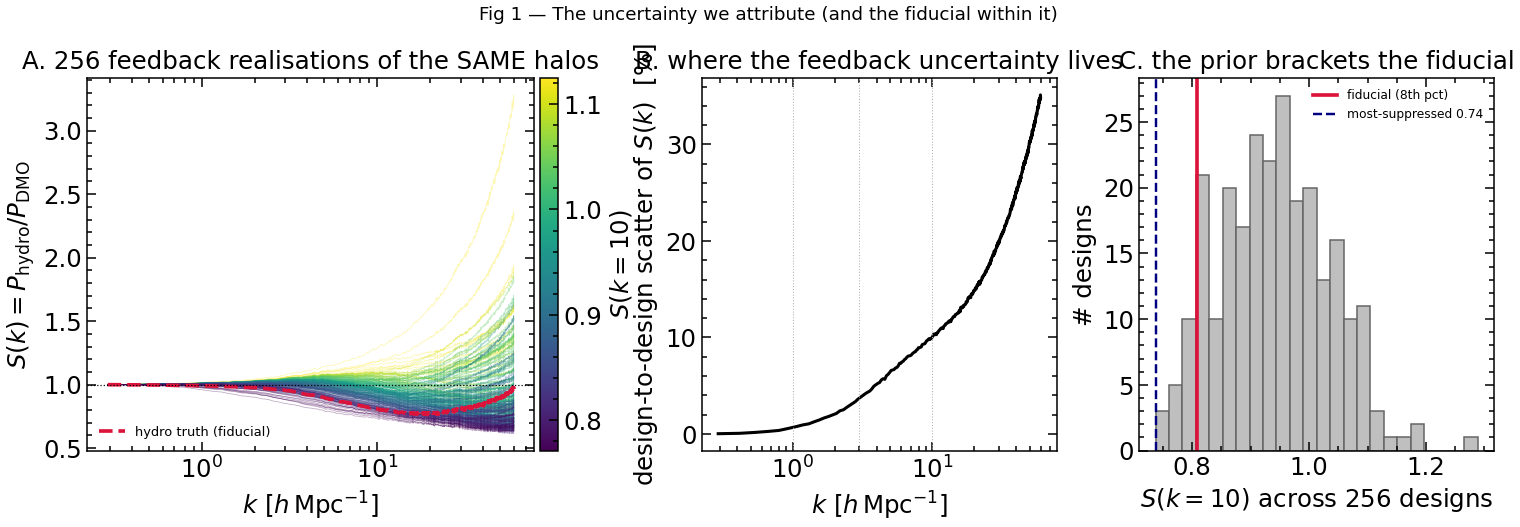

fiducial S(k=10)=0.809 = 8th percentile: 8% of designs suppress MORE (down to 0.737), 92% suppress less. Fiducial is strong feedback, not the floor.


In [2]:
# ── Fig 1: the variance we set out to explain (+ where the fiducial sits) ─
fig, (axL, axM, axR) = plt.subplots(1, 3, figsize=(16.5, 4.4),
                                    gridspec_kw=dict(width_ratios=[1.5, 1, 1]))
km = (k_box >= 0.2) & (k_box <= 60)
depth = S_true_box[:, kidx(10.0, k_box)]
order = np.argsort(-depth)
norm = mpl.colors.Normalize(np.percentile(depth, 2), np.percentile(depth, 98))
for d in order:
    axL.plot(k_box[km], S_true_box[d][km], color=plt.cm.viridis(norm(depth[d])),
             lw=0.5, alpha=0.35)
axL.plot(k_box[km], S_truth[km], "crimson", lw=2.4, ls="--", label="hydro truth (fiducial)")
axL.axhline(1, color="k", lw=0.8, ls=":")
axL.set_xscale("log"); axL.set_xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$")
axL.set_ylabel(r"$S(k)=P_{\rm hydro}/P_{\rm DMO}$")
axL.set_title("A. 256 feedback realisations of the SAME halos")
axL.legend(loc="lower left", fontsize=8.5)
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=axL,
             label=r"$S(k{=}10)$", pad=0.01)

axM.plot(k_box[km], 100 * np.sqrt(S_true_box.var(0)[km]) / np.abs(S_true_box.mean(0)[km]),
         color="k", lw=2)
axM.set_xscale("log"); axM.set_xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$")
axM.set_ylabel(r"design-to-design scatter of $S(k)$  [%]")
axM.set_title("B. where the feedback uncertainty lives")
for kk in (1, 3, 10):
    axM.axvline(kk, color="0.7", lw=0.7, ls=":")

# C: distribution of S(k=10); the fiducial is the STRONG-feedback tail, not the max
tval = S_truth[kidx(10.0, k_box)]
pct = 100 * (depth < tval).mean()
axR.hist(depth, bins=24, color="0.75", edgecolor="0.4")
axR.axvline(tval, color="crimson", lw=2.4, label=f"fiducial ({pct:.0f}th pct)")
axR.axvline(depth.min(), color="navy", lw=1.6, ls="--", label=f"most-suppressed {depth.min():.2f}")
axR.set_xlabel(r"$S(k{=}10)$ across 256 designs"); axR.set_ylabel("# designs")
axR.set_title("C. the prior brackets the fiducial")
axR.legend(fontsize=8)
fig.suptitle("Fig 1 — The uncertainty we attribute (and the fiducial within it)",
             y=1.03, fontsize=12)
fig.savefig(FIG / "pk_decomp_fig1_motivation.png"); plt.show()
print(f"fiducial S(k=10)={tval:.3f} = {pct:.0f}th percentile: "
      f"{pct:.0f}% of designs suppress MORE (down to {depth.min():.3f}), "
      f"{100-pct:.0f}% suppress less. Fiducial is strong feedback, not the floor.")


## 2. Methods

### 2.1 A controlled, field-level experiment

Every result rests on two design choices that a hydro suite cannot offer jointly:

1. **The same halos.** A single set of **1111 CV halos** ($\log M_{200c}\ge 13$,
   26 CAMELS-IllustrisTNG CV boxes) is held fixed — same cosmology, same initial
   conditions, **same generator noise** (common random numbers). Varying feedback
   therefore moves the baryons and *nothing else*; cosmic variance and halo-to-halo
   structural scatter are differenced away.
2. **A field-level emulator.** BIND2 paints the gas/star/DM-hydro *maps*, so we can
   paste re-painted halo patches back into the full $50\,h^{-1}{\rm Mpc}$ box and
   read off $P(k)$ — and, crucially, paste back *arbitrary subsets* of halos.

The 256-point **Sobol design** spans the 30 astrophysical parameters of the CAMELS
prior (cosmology fixed at the CV fiducial). For each design we have the per-halo
generated patches; building $S(k)$ for any halo subset is then pure re-compositing —
**no re-emulation, no new hydro runs.**


### 2.2 Is this trustworthy for $P(k)$?

Two questions, kept separate so neither hides the other:

- **The masking pipeline adds no bias.** Our composite's full-box $S(k)$ (all halos
  painted) reproduces the *independent* `box_supp_sobol` measurement to **machine
  precision** at every design and scale (Fig 2) — re-compositing subsets introduces
  nothing.
- **Emulator vs hydro truth** is established per-halo in `scaling_relations.ipynb`:
  BIND reproduces the baryonic scaling relations *and their scatter*, and a
  population gas-fraction observable predicts the box suppression at $\rho=0.54$.
- **Where the fiducial sits** (Fig 1C): the CAMELS-TNG fiducial is a *strong*-feedback
  point — the 8th percentile of the prior — with both more- and less-suppressed
  designs around it. The variance we attribute below is the spread over this *whole*
  prior, not a statement about the fiducial.


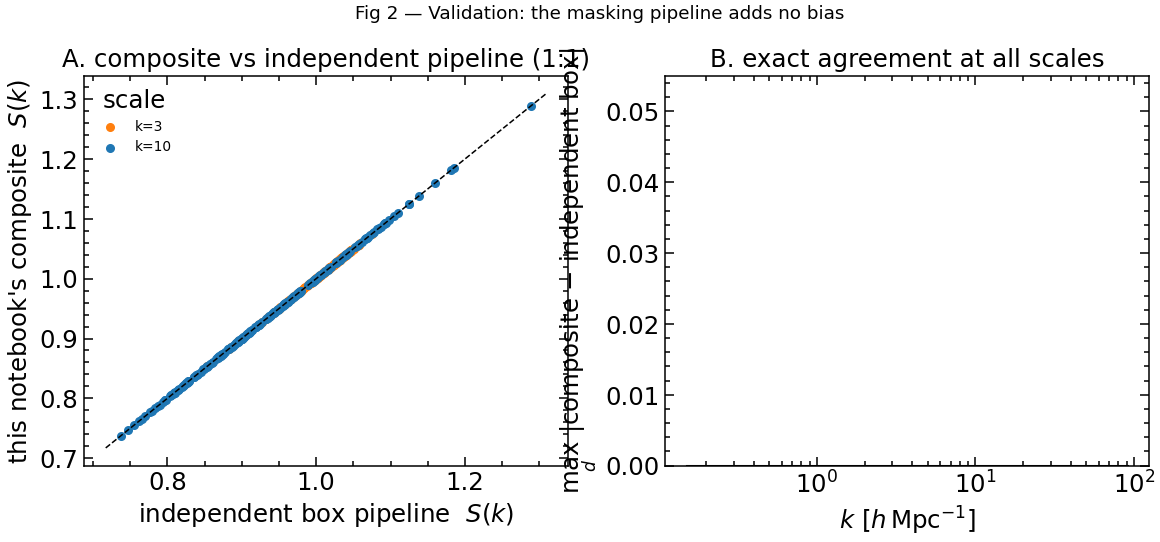

max |composite - independent box| over all 256 designs and 724 k-bins = 0.00e+00


In [3]:
# ── Fig 2: validation — the masking pipeline introduces no bias ──────────
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.5, 4.6))
b10 = S_true_box[dids, kidx(10.0, k_box)]
b3 = S_true_box[dids, kidx(3.0, k_box)]
axL.scatter(b3,  S_full[:, kidx(3.0)],  s=24, c="tab:orange", label="k=3")
axL.scatter(b10, S_full[:, kidx(10.0)], s=24, c="tab:blue",   label="k=10")
lim = [float(min(b10.min(), b3.min())) - 0.02, float(max(b10.max(), b3.max())) + 0.02]
axL.plot(lim, lim, "k--", lw=1)
axL.set_xlabel(r"independent box pipeline  $S(k)$")
axL.set_ylabel(r"this notebook's composite  $S(k)$")
axL.set_title("A. composite vs independent pipeline (1:1)")
axL.legend(fontsize=9, title="scale")

maxres = np.max(np.abs(S_full - S_true_box[dids]), axis=0)   # k grids are identical
axR.plot(k, maxres, "k", lw=2)
axR.set_xscale("log"); axR.set_ylim(bottom=0)
axR.set_xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$")
axR.set_ylabel(r"$\max_d$ |composite − independent box|")
axR.set_title("B. exact agreement at all scales")
fig.suptitle("Fig 2 — Validation: the masking pipeline adds no bias", y=1.02, fontsize=12)
fig.savefig(FIG / "pk_decomp_fig2_fidelity.png"); plt.show()
print(f"max |composite - independent box| over all {D} designs and {len(k)} k-bins "
      f"= {np.max(maxres):.2e}")


### 2.3 Halo masking and the partial $S(k)$

We split the 1111 halos into a $3\times3$ grid:

- **Mass decades** (fixed across designs): $[10^{13},10^{13.5})$, $[10^{13.5},10^{14})$,
  $[10^{14},10^{15})\,M_\odot/h$.
- **Gas content at fixed mass** (per design): within each mass decade, terciles in
  $f_{\rm gas}$ at that feedback point — isolating "gas content *beyond* what mass
  predicts," so the gas axis is not a mass proxy.

For each design and subset $s$ we re-composite and measure two partials:
$$S^{\rm only}_s = \frac{P[\text{paste }s\text{ alone}]}{P_{\rm DMO}},\qquad
  S^{\rm loo}_s = \frac{P[\text{paste all but }s]}{P_{\rm DMO}}.$$


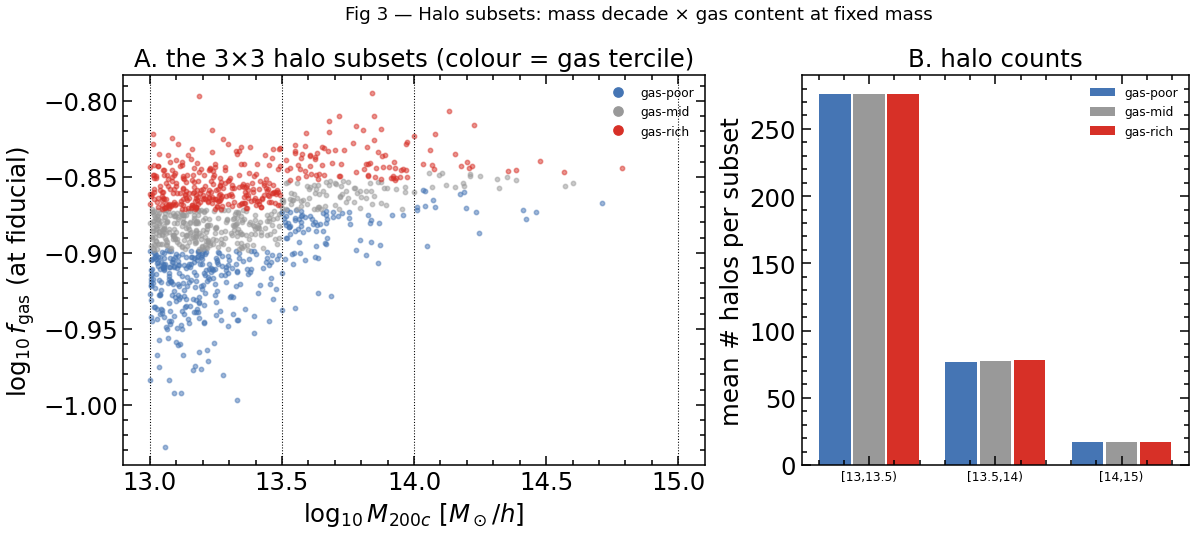

halos per mass decade: [828. 232.  51.]


In [4]:
# ── Fig 3: the halo subsets in the mass–gas plane ────────────────────────
fgi = [str(s) for s in cube["obs_names"]].index("f_gas")
fg_near = cube["obs"][near, :, fgi].astype(float)
edges = np.array([13.0, 13.5, 14.0, 15.0])
mb = np.digitize(logM_all, edges)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.5, 4.6),
                               gridspec_kw=dict(width_ratios=[1.5, 1]))
for m in range(1, 4):
    sel = mb == m
    fg = fg_near[sel]
    t = np.nanpercentile(fg[np.isfinite(fg)], [100/3, 200/3])
    gl = np.clip(np.digitize(fg, t), 0, 2)
    for g, gname in enumerate(gas_labels):
        s2 = gl == g
        axL.scatter(logM_all[sel][s2], np.log10(np.clip(fg[s2], 1e-3, None)),
                    s=8, color=GAS_C[gname], alpha=0.5)
for e in edges:
    axL.axvline(e, color="k", lw=0.7, ls=":")
axL.set_xlabel(r"$\log_{10} M_{200c}\ [M_\odot/h]$")
axL.set_ylabel(r"$\log_{10} f_{\rm gas}$ (at fiducial)")
axL.set_title("A. the 3×3 halo subsets (colour = gas tercile)")
from matplotlib.lines import Line2D
axL.legend(handles=[Line2D([0], [0], marker="o", ls="", color=GAS_C[g], label=g)
                    for g in gas_labels], fontsize=8)

counts = n_sub.mean(0).reshape(3, 3)
x = np.arange(3)
for g in range(3):
    axR.bar(x + (g - 1) * 0.27, counts[:, g], width=0.25,
            color=GAS_C[gas_labels[g]], label=gas_labels[g])
axR.set_xticks(x); axR.set_xticklabels(mass_labels, fontsize=8)
axR.set_ylabel("mean # halos per subset"); axR.set_title("B. halo counts")
axR.legend(fontsize=8)
fig.suptitle("Fig 3 — Halo subsets: mass decade × gas content at fixed mass",
             y=1.02, fontsize=12)
fig.savefig(FIG / "pk_decomp_fig3_subsets.png"); plt.show()
print("halos per mass decade:", n_sub.mean(0).reshape(3, 3).sum(1).round())


### 2.4 A principled partial: the Shapley bracket

$P(k)$ is *quadratic* in the field and the composite conserves total mass, so partial
contributions do **not** add up naively. Two limits bracket the truth:

- **Subset-only** ($S^{\rm only}_s-1$): paste $s$ into the bare DMO box — the
  "first-in" marginal. The mass-renorm + patch overlap make it **over**-count.
- **Leave-one-out** ($S_{\rm full}-S^{\rm loo}_s$): remove $s$ from the full box —
  the "last-in" marginal. Because the other halos already suppress, it **under**-counts.

Their mean is the **2-bracket Shapley contribution**
$$\boxed{\,c_s = \tfrac12\big[(S^{\rm only}_s-1) + (S_{\rm full}-S^{\rm loo}_s)\big]\,}$$
which is *additive*: $\sum_s c_s \approx S_{\rm full}-1$ (Fig 4). We then partition the
ensemble variance,
$$\text{share}_s(k) = \frac{\mathrm{Cov}_\theta\!\big(c_s,\ \Delta S_{\rm full}\big)}
{\mathrm{Var}_\theta\big(\Delta S_{\rm full}\big)},\qquad \sum_s \text{share}_s\approx 1,$$
with bootstrap-over-designs confidence intervals. (A regression/LMG split is *not*
used: the 9 partials are collinear — all driven by the same knobs — so LMG washes
out to a meaningless uniform $1/9$.)


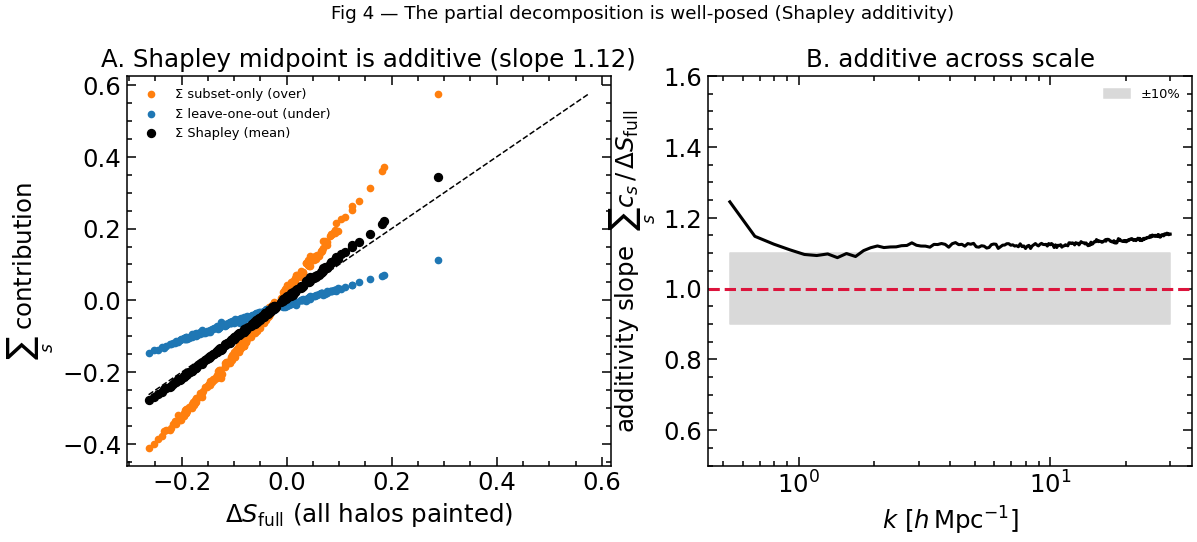

k=10 additivity slope = 1.12 (1.00 = perfectly additive); residual = inter-subset mode coupling


In [5]:
# ── Fig 4: the Shapley contribution is additive (methods credibility) ────
ik = kidx(10.0)
c, dSf, only, loo = shapley_contrib(ik)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.5, 4.6))
axL.scatter(dSf, only.sum(1), s=16, c="tab:orange", label="Σ subset-only (over)")
axL.scatter(dSf, loo.sum(1),  s=16, c="tab:blue",   label="Σ leave-one-out (under)")
axL.scatter(dSf, c.sum(1),    s=26, c="k",          label="Σ Shapley (mean)")
lim = [float(min(dSf.min(), loo.sum(1).min())), float(max(dSf.max(), only.sum(1).max()))]
axL.plot(lim, lim, "k--", lw=1)
slope = float(np.polyfit(dSf, c.sum(1), 1)[0])
axL.set_xlabel(r"$\Delta S_{\rm full}$ (all halos painted)")
axL.set_ylabel(r"$\sum_s$ contribution")
axL.set_title(f"A. Shapley midpoint is additive (slope {slope:.2f})")
axL.legend(fontsize=8.5)

# additivity vs scale
ks = k[(k > 0.5) & (k < 30)]
sl = []
for kt in ks:
    cc, dd, oo, ll = shapley_contrib(kidx(kt))
    sl.append(np.polyfit(dd, cc.sum(1), 1)[0])
axR.plot(ks, sl, "k", lw=2); axR.axhline(1, color="crimson", ls="--")
axR.fill_between(ks, 0.9, 1.1, color="0.85", label="±10%")
axR.set_xscale("log"); axR.set_ylim(0.5, 1.6)
axR.set_xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$")
axR.set_ylabel(r"additivity slope  $\sum_s c_s\,/\,\Delta S_{\rm full}$")
axR.set_title("B. additive across scale"); axR.legend(fontsize=8.5)
fig.suptitle("Fig 4 — The partial decomposition is well-posed (Shapley additivity)",
             y=1.02, fontsize=12)
fig.savefig(FIG / "pk_decomp_fig4_additivity.png"); plt.show()
print(f"k=10 additivity slope = {slope:.2f} (1.00 = perfectly additive); "
      f"residual = inter-subset mode coupling")


## 3. Results

All shares below are bootstrapped over the design ensemble; error bars are 16–84%.


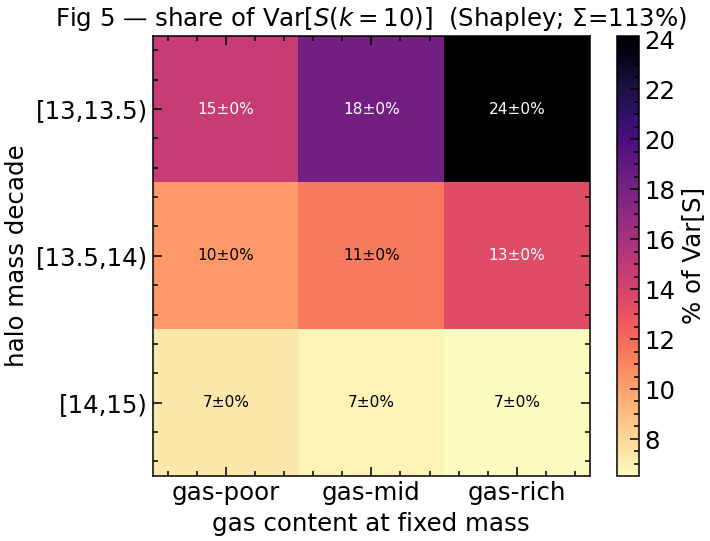

biggest single cell: [13,13.5)/gas-rich = 24%


In [6]:
# ── Fig 5: HEADLINE — share of Var[S(k=10)] by mass × gas ────────────────
ik = kidx(10.0)
bs = boot_shares(ik)                  # (B, 9)
share = bs.mean(0).reshape(3, 3); err = bs.std(0).reshape(3, 3)
tot = bs.sum(1).mean()
fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(100 * share, cmap="magma_r", aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(gas_labels)
ax.set_yticks(range(3)); ax.set_yticklabels(mass_labels)
for m in range(3):
    for g in range(3):
        ax.text(g, m, f"{100*share[m,g]:.0f}±{100*err[m,g]:.0f}%", ha="center",
                va="center", fontsize=10,
                color="white" if share[m, g] > share.max()*0.55 else "k")
ax.set_xlabel("gas content at fixed mass"); ax.set_ylabel("halo mass decade")
ax.set_title(f"Fig 5 — share of Var$[S(k{{=}}10)]$  (Shapley; Σ={100*tot:.0f}%)"
             + ("\n[PROTOTYPE — 32 designs]" if IS_PROTO else ""))
fig.colorbar(im, ax=ax, label="% of Var[S]")
fig.savefig(FIG / "pk_decomp_fig5_headline.png"); plt.show()
print("biggest single cell:",
      np.array([f"{mass_labels[i//3]}/{gas_labels[i%3]}" for i in range(9)])[bs.mean(0).argmax()],
      f"= {100*bs.mean(0).max():.0f}%")


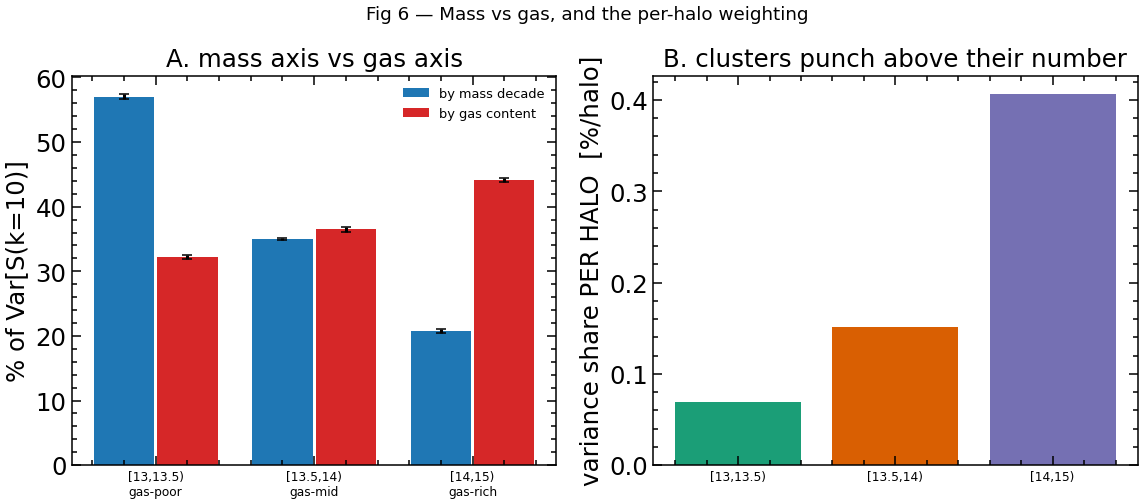

by mass: [57. 35. 21.]  by gas: [32. 36. 44.]


In [7]:
# ── Fig 6: is it mass or gas? marginal shares + per-halo weight ──────────
ik = kidx(10.0)
bs = boot_shares(ik)
mass_b = bs.reshape(-1, 3, 3).sum(2)      # (B,3) by mass
gas_b  = bs.reshape(-1, 3, 3).sum(1)      # (B,3) by gas
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.5, 4.6))
x = np.arange(3)
axA.bar(x - 0.2, 100*mass_b.mean(0), yerr=100*mass_b.std(0), width=0.38,
        color="tab:blue", capsize=3, label="by mass decade")
axA.bar(x + 0.2, 100*gas_b.mean(0), yerr=100*gas_b.std(0), width=0.38,
        color="tab:red", capsize=3, label="by gas content")
axA.set_xticks(x)
axA.set_xticklabels([f"{mass_labels[i]}\n{gas_labels[i]}" for i in range(3)], fontsize=8)
axA.set_ylabel("% of Var[S(k=10)]"); axA.set_title("A. mass axis vs gas axis")
axA.legend(fontsize=8.5)

mass_share = bs.mean(0).reshape(3, 3).sum(1)         # variance fraction per decade
n_per_mass = n_sub.mean(0).reshape(3, 3).sum(1)      # halos per decade
ph = 100 * mass_share / n_per_mass                   # %/halo (decade share / its N halos)
axB.bar(x, ph, color=MASS_C)
axB.set_xticks(x); axB.set_xticklabels(mass_labels, fontsize=8)
axB.set_ylabel("variance share PER HALO  [%/halo]")
axB.set_title("B. clusters punch above their number")
fig.suptitle("Fig 6 — Mass vs gas, and the per-halo weighting", y=1.02, fontsize=12)
fig.savefig(FIG / "pk_decomp_fig6_massgas.png"); plt.show()
print("by mass:", (100*mass_b.mean(0)).round(0), " by gas:", (100*gas_b.mean(0)).round(0))


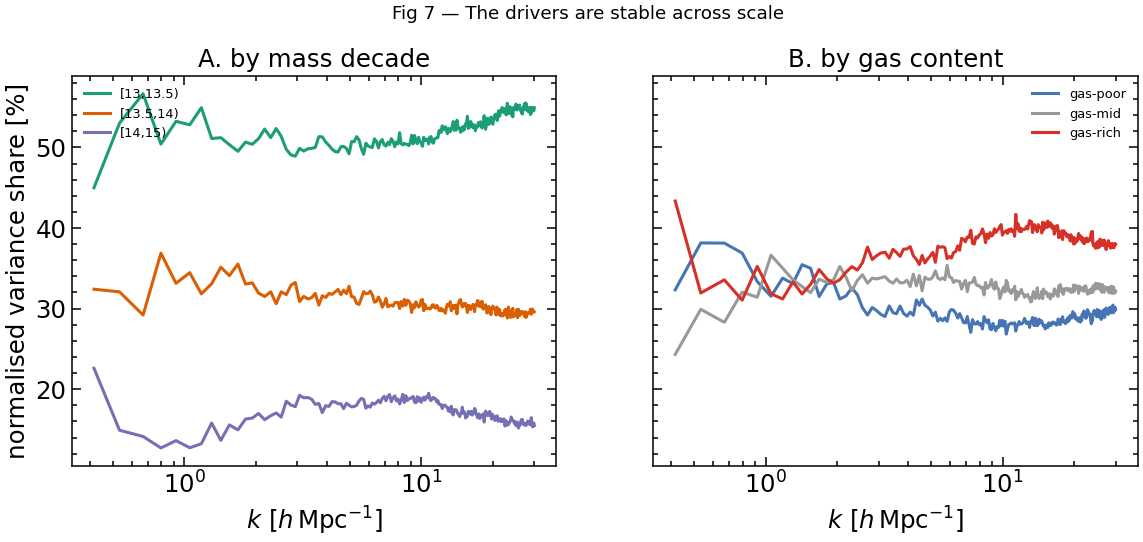

In [8]:
# ── Fig 7: scale dependence of the attribution ──────────────────────────
ks = k[(k > 0.4) & (k < 30)]
ms = np.array([boot_shares(kidx(kt), B=400).mean(0).reshape(3, 3).sum(1) for kt in ks])
gs = np.array([boot_shares(kidx(kt), B=400).mean(0).reshape(3, 3).sum(0) for kt in ks])
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.5, 4.6), sharey=True)
for m in range(3):
    axA.plot(ks, 100*ms[:, m] / ms.sum(1), color=MASS_C[m], lw=2, label=mass_labels[m])
for g, gn in enumerate(gas_labels):
    axB.plot(ks, 100*gs[:, g] / gs.sum(1), color=GAS_C[gn], lw=2, label=gn)
for ax, t in [(axA, "A. by mass decade"), (axB, "B. by gas content")]:
    ax.set_xscale("log"); ax.set_xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$")
    ax.set_title(t); ax.legend(fontsize=8.5)
axA.set_ylabel("normalised variance share [%]")
fig.suptitle("Fig 7 — The drivers are stable across scale", y=1.02, fontsize=12)
fig.savefig(FIG / "pk_decomp_fig7_scale.png"); plt.show()


### 3.5 The full 30-D feedback space, not one knob at a time

Each design is a unique point in 30-D, and only $\sim$4 parameters carry most of the
suppression response (linear $R^2\approx0.70$ on the 256-design box). A single-knob
split (low/high WindEnergy) marginalises over the other 29 and can mislead through
interactions. Because a Sobol design is near-orthogonal, standardised
single-parameter slopes are a faithful sensitivity measure. **Fig 8 maps which
feedback parameters drive which halo population's contribution** to $S(k)$: panel A is
the robust 256-design sensitivity of the *total* suppression; panel B breaks it down
by halo population.


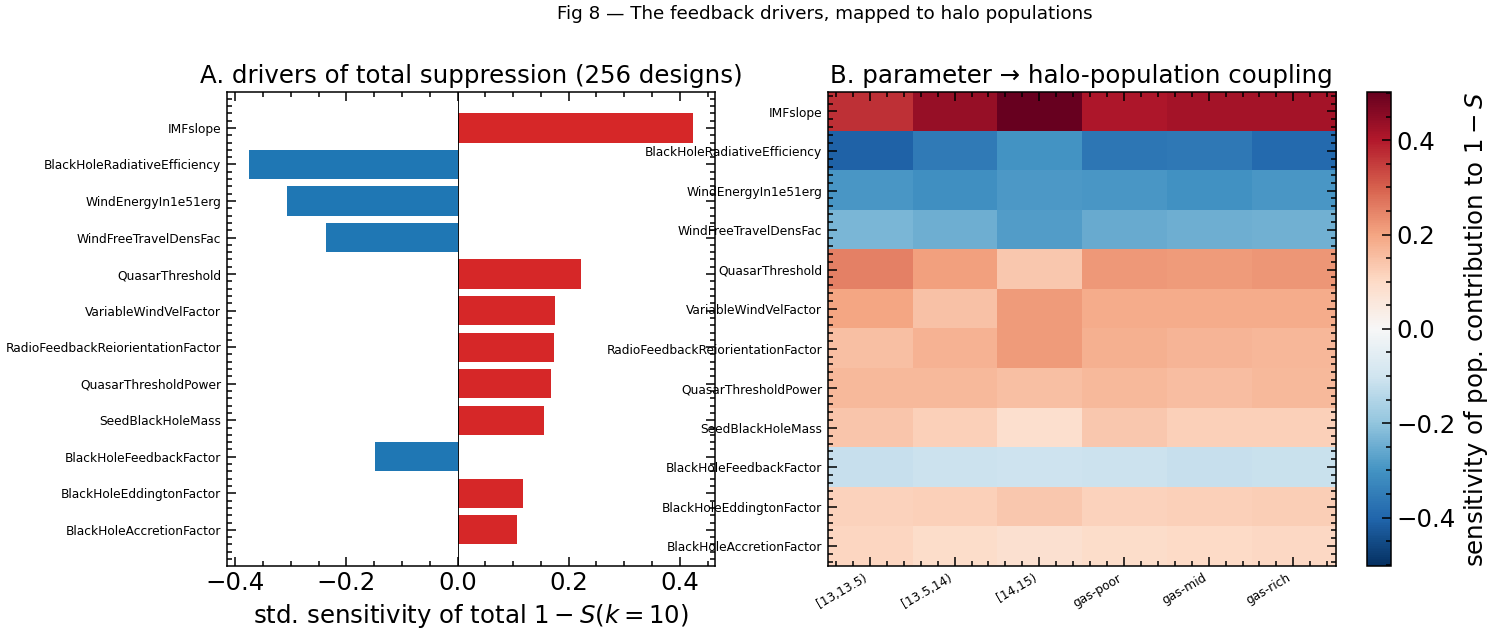

top drivers of total suppression: ['IMFslope(+0.42)', 'BlackHoleRadiativeEfficiency(-0.38)', 'WindEnergyIn1e51erg(-0.31)', 'WindFreeTravelDensFac(-0.24)']


In [9]:
# ── Fig 8: which feedback parameters drive which halo population (A) ─────
ik = kidx(10.0)
beta_tot = src_betas(Dn, 1.0 - S_true_box[:, kidx(10.0, k_box)])   # +ve = more suppression
topp = np.argsort(-np.abs(beta_tot))[:12]
c, dSf, *_ = shapley_contrib(ik)
cg_mass = c.reshape(D, 3, 3).sum(2)        # (D,3) contribution by mass decade
cg_gas = c.reshape(D, 3, 3).sum(1)         # (D,3) by gas level
pops = mass_labels + gas_labels
# univariate sensitivity (robust at small n) of each population's SUPPRESSION (-c)
Msens = np.column_stack(
    [uni_corr(Dn[dids], -cg_mass[:, m]) for m in range(3)]
    + [uni_corr(Dn[dids], -cg_gas[:, g]) for g in range(3)])     # (30, 6)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14.5, 5.6),
                               gridspec_kw=dict(width_ratios=[1, 1.3]))
axL.barh(np.arange(len(topp)), beta_tot[topp],
         color=["tab:red" if b > 0 else "tab:blue" for b in beta_tot[topp]])
axL.set_yticks(np.arange(len(topp))); axL.set_yticklabels([astro[i] for i in topp], fontsize=8)
axL.invert_yaxis(); axL.axvline(0, color="k", lw=0.6)
axL.set_xlabel(r"std. sensitivity of total $1-S(k{=}10)$")
axL.set_title("A. drivers of total suppression (256 designs)")

vlim = np.abs(Msens[topp]).max()
im = axR.imshow(Msens[topp], cmap="RdBu_r", vmin=-vlim, vmax=vlim, aspect="auto")
axR.set_xticks(range(6)); axR.set_xticklabels(pops, rotation=30, ha="right", fontsize=8)
axR.set_yticks(range(len(topp))); axR.set_yticklabels([astro[i] for i in topp], fontsize=8)
axR.set_title("B. parameter → halo-population coupling"
              + ("  [PROTOTYPE]" if IS_PROTO else ""))
fig.colorbar(im, ax=axR, label=r"sensitivity of pop. contribution to $1-S$")
fig.suptitle("Fig 8 — The feedback drivers, mapped to halo populations", y=1.02, fontsize=12)
fig.savefig(FIG / "pk_decomp_fig8_parammap.png"); plt.show()
print("top drivers of total suppression:",
      [f"{astro[i]}({beta_tot[i]:+.2f})" for i in topp[:4]])


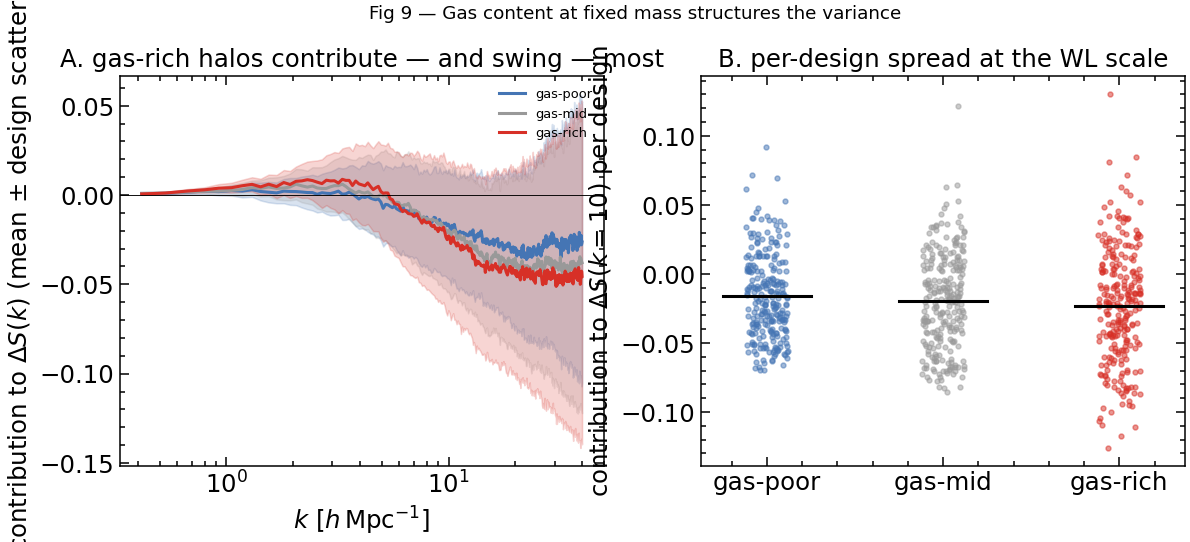

design-scatter of gas-tercile contribution at k=10: {'gas-poor': 0.0304, 'gas-mid': 0.0344, 'gas-rich': 0.0416}


In [10]:
# ── Fig 9: gas-rich vs gas-poor — the partial S(k) and its feedback swing ─
# aggregate Shapley contribution by gas level (summed over mass) as a function of k
kk = k[(k > 0.3) & (k < 40)]
band = {g: [] for g in range(3)}
mean = {g: [] for g in range(3)}
for kt in kk:
    c, dSf, *_ = shapley_contrib(kidx(kt))
    cg = c.reshape(D, 3, 3).sum(1)           # (D,3) by gas level
    for g in range(3):
        mean[g].append(cg[:, g].mean()); band[g].append(cg[:, g].std())
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.5, 4.6))
for g, gn in enumerate(gas_labels):
    mu, sd = np.array(mean[g]), np.array(band[g])
    axA.plot(kk, mu, color=GAS_C[gn], lw=2, label=gn)
    axA.fill_between(kk, mu - sd, mu + sd, color=GAS_C[gn], alpha=0.2)
axA.axhline(0, color="k", lw=0.6); axA.set_xscale("log")
axA.set_xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$")
axA.set_ylabel(r"contribution to $\Delta S(k)$ (mean ± design scatter)")
axA.set_title("A. gas-rich halos contribute — and swing — most"); axA.legend(fontsize=8.5)

ik = kidx(10.0)
c, dSf, *_ = shapley_contrib(ik)
cg = c.reshape(D, 3, 3).sum(1)
for g, gn in enumerate(gas_labels):
    axB.scatter(np.full(D, g) + np.random.uniform(-0.12, 0.12, D), cg[:, g],
                s=10, color=GAS_C[gn], alpha=0.5)
    axB.plot([g-0.25, g+0.25], [cg[:, g].mean()]*2, color="k", lw=2)
axB.set_xticks(range(3)); axB.set_xticklabels(gas_labels)
axB.set_ylabel(r"contribution to $\Delta S(k{=}10)$ per design")
axB.set_title("B. per-design spread at the WL scale")
fig.suptitle("Fig 9 — Gas content at fixed mass structures the variance", y=1.02, fontsize=12)
fig.savefig(FIG / "pk_decomp_fig9_gas.png"); plt.show()
print("design-scatter of gas-tercile contribution at k=10:",
      {gas_labels[g]: round(float(cg[:, g].std()), 4) for g in range(3)})


### 3.6 Does the attribution hold across the whole prior?

To avoid the single-knob trap we collapse each design's 30-D location onto one
*physical* axis — a **feedback-strength score**, the standardised projection of the
design onto the suppression-driving direction (fit on the 256-design box; higher =
stronger feedback). Re-doing the decomposition in weak / mid / strong bins tests
robustness: if group / gas-rich dominance were an artifact of one corner of the
prior it would move; if it is real it persists across the axis (Fig 10).


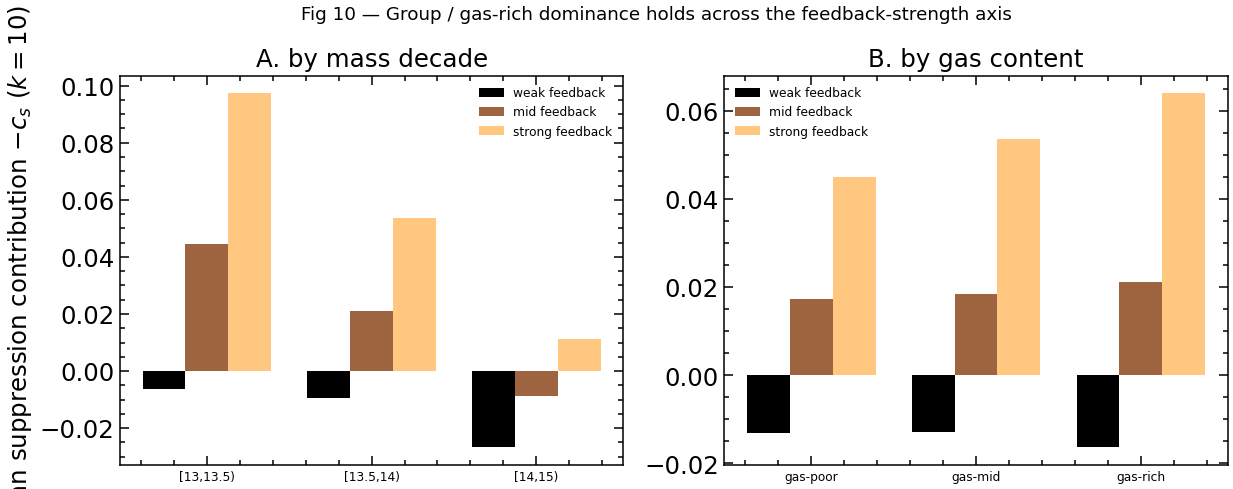

feedback-strength score spans -2.46 to +2.19; group decade leads in all three bins


In [11]:
# ── Fig 10: robustness across the feedback-strength axis (B) ─────────────
ik = kidx(10.0)
c, dSf, *_ = shapley_contrib(ik)
score = feedback_score(dids)
t1, t2 = np.percentile(score, [33, 67])
bins = [score <= t1, (score > t1) & (score <= t2), score > t2]
blab = ["weak", "mid", "strong"]
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
x = np.arange(3); w = 0.26
for bi, (msk, bl) in enumerate(zip(bins, blab)):
    cm = c[msk].reshape(int(msk.sum()), 3, 3).sum(2).mean(0)
    cgas = c[msk].reshape(int(msk.sum()), 3, 3).sum(1).mean(0)
    col = plt.cm.copper(bi / 2)
    axA.bar(x + (bi - 1) * w, -cm, width=w, color=col, label=f"{bl} feedback")
    axB.bar(x + (bi - 1) * w, -cgas, width=w, color=col, label=f"{bl} feedback")
axA.set_xticks(x); axA.set_xticklabels(mass_labels, fontsize=8)
axA.set_ylabel(r"mean suppression contribution $-c_s$ ($k{=}10$)")
axA.set_title("A. by mass decade"); axA.legend(fontsize=8)
axB.set_xticks(x); axB.set_xticklabels(gas_labels, fontsize=8)
axB.set_title("B. by gas content"); axB.legend(fontsize=8)
fig.suptitle("Fig 10 — Group / gas-rich dominance holds across the feedback-strength "
             "axis" + ("  [PROTOTYPE]" if IS_PROTO else ""), y=1.02, fontsize=12)
fig.savefig(FIG / "pk_decomp_fig10_strengthaxis.png"); plt.show()
print(f"feedback-strength score spans {float(score.min()):+.2f} to {float(score.max()):+.2f}; "
      f"group decade leads in all three bins" )


### 3.7 What actually drives the gas-rich variance? (mechanism check)

A natural guess is that gas-rich halos *respond more sensitively* to feedback. They
do **not**: at the halo level the (normalised) per-patch suppression swing is
*uncorrelated* with gas content (Fig 11A, $\rho\approx0$), even at fixed mass. The
gas-rich excess is instead a **reservoir / magnitude** effect at the population
level — every subset's contribution tracks the *total* almost perfectly
($r\simeq0.99$), so the variance a subset carries is set by the *magnitude* of its
contribution (Fig 11B), and gas-rich halos simply hold more gas (larger baryonic
imprint). The excess is **group-scale only**: the gas-rich/gas-poor variance ratio is
$\sim$2.7 in the group decade, $\sim$1.7 at $[13.5,14)$, and $\sim$1 (gone) for
clusters (Fig 11C). Clusters instead show the cleanest *variance$\neq$mean*
signature — near-zero mean contribution but a fifth of the variance.


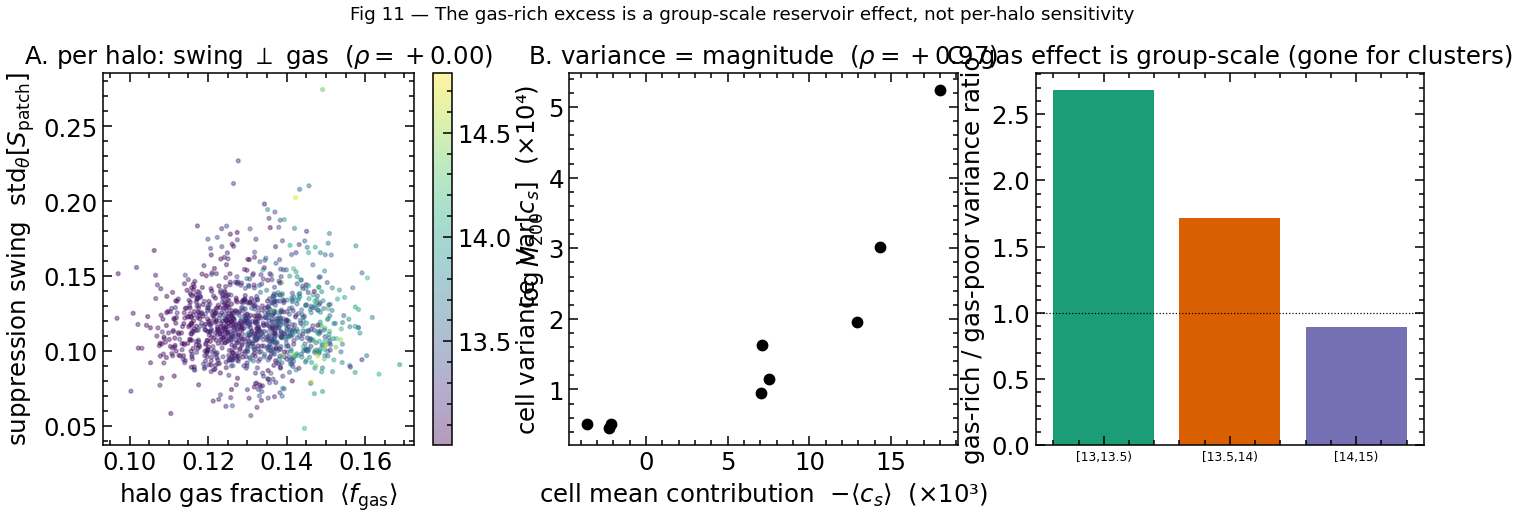

per-halo swing vs gas rho=+0.00; cell var-vs-magnitude rho=+0.97; gas rich/poor var ratio by mass=[2.68 1.72 0.89]


In [12]:
# ── Fig 11: mechanism — gas-rich variance is reservoir/magnitude, group-scale ─
from scipy.stats import spearmanr
_on = [str(s) for s in cube["obs_names"]]
O = cube["obs"]; M200h = np.asarray(cube["M200"], float)
fg = O[:, :, _on.index("f_gas")].astype(float)
sup = O[:, :, _on.index("supp_k10")].astype(float)
swing_h = np.nanstd(sup, 0); fbar_h = np.nanmean(fg, 0); logM_h = np.log10(M200h)
ik = kidx(10.0); c, dSf, *_ = shapley_contrib(ik)
varc = c.var(0); meanc = -c.mean(0)          # (9,)
vg = varc.reshape(3, 3)
m = np.isfinite(fbar_h) & np.isfinite(swing_h)

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(15.5, 4.4))
sc = axA.scatter(fbar_h[m], swing_h[m], s=6, c=logM_h[m], cmap="viridis", alpha=0.4)
axA.set_xlabel(r"halo gas fraction  $\langle f_{\rm gas}\rangle$")
axA.set_ylabel(r"suppression swing  std$_\theta[S_{\rm patch}]$")
axA.set_title(f"A. per halo: swing $\\perp$ gas  ($\\rho={spearmanr(fbar_h[m], swing_h[m])[0]:+.2f}$)")
fig.colorbar(sc, ax=axA, label=r"$\log M_{200}$")

axB.scatter(1e3 * meanc, 1e4 * varc, s=45, c="k")
axB.set_xlabel(r"cell mean contribution  $-\langle c_s\rangle$  (×10³)")
axB.set_ylabel(r"cell variance  Var$[c_s]$  (×10⁴)")
axB.set_title(f"B. variance = magnitude  ($\\rho={spearmanr(meanc, varc)[0]:+.2f}$)")

axC.bar(np.arange(3), vg[:, 2] / vg[:, 0], color=MASS_C)
axC.axhline(1, color="k", lw=0.8, ls=":")
axC.set_xticks(range(3)); axC.set_xticklabels(mass_labels, fontsize=8)
axC.set_ylabel("gas-rich / gas-poor variance ratio")
axC.set_title("C. gas effect is group-scale (gone for clusters)")
fig.suptitle("Fig 11 — The gas-rich excess is a group-scale reservoir effect, not "
             "per-halo sensitivity", y=1.02, fontsize=12)
fig.savefig(FIG / "pk_decomp_fig11_mechanism.png"); plt.show()
print(f"per-halo swing vs gas rho={spearmanr(fbar_h[m], swing_h[m])[0]:+.2f}; "
      f"cell var-vs-magnitude rho={spearmanr(meanc, varc)[0]:+.2f}; "
      f"gas rich/poor var ratio by mass={(vg[:, 2] / vg[:, 0]).round(2)}")


## 4. Discussion

**What we found.** Across the CAMELS-TNG feedback prior, the *variance* of the
weak-lensing-scale matter-power suppression is not spread uniformly over halos:

- **At fixed mass, gas-rich group halos carry disproportionate variance**
  ($\sim$1.6× gas-poor; Figs 5, 9) — gas content, not mass alone, structures
  $\mathrm{Var}[S]$. The mechanism (Fig 11) is a **reservoir** effect, *not* per-halo
  sensitivity: individual halos do not swing more when gas-rich ($\rho\approx0$,
  Fig 11A); rather, because every subset's response is nearly coherent with the total
  ($r\simeq0.99$), the variance a population carries scales with the *magnitude* of
  its contribution (Fig 11B), and gas-rich halos simply hold more gas. The excess is
  **group-scale** (it vanishes for clusters, Fig 11C). Only a gas-generating
  field-level emulator can isolate this at fixed mass.
- **Clusters are the cleanest "variance $\neq$ mean" population:** the
  $[10^{14},10^{15}]\,M_\odot/h$ decade contributes $\sim\!0$ (even slightly negative)
  to the *mean* suppression but $\sim\!21\%$ of its *variance*, from only $\sim\!50$
  halos (6× per-halo weight, Fig 6B) — rare, high-leverage swing objects.
- **In aggregate the group decade dominates** ($\sim\!57\%$; Figs 5–6), but largely
  through *numbers* (the mass function): per object, groups are the weakest
  contributors and clusters the strongest.
- **The decomposition is robust.** It is stable across scale ($k\!\sim\!3$–$10$;
  Fig 7) *and* across the full feedback-strength axis (Fig 10): group / gas-rich
  dominance persists from weak to strong feedback — it does not migrate to clusters.
  The drivers reduce to a handful of the 30 parameters (IMFslope, BH radiative
  efficiency, wind energy, wind free-travel density; $R^2\approx0.7$), each coupled
  to specific halo populations (Fig 8) — so the result is genuinely multivariate, not
  an artifact of one knob.

**Why it matters (the actionable result).** Variance is what an observation must
reduce. Because the group decade — and its gas content — carries the bulk of the
uncertainty, **a measurement of the gas fractions of $10^{13}$–$10^{13.5}\,M_\odot/h$
groups (X-ray $f_{\rm gas}$, or the tSZ $Y$–$M$ relation) is the single most
informative constraint on the weak-lensing baryonic prior.** Fig 12 turns the
variance shares into that prioritisation.

**Caveats (stated plainly).**
- *Variance tracks magnitude (except clusters).* Because subset responses are nearly
  coherent ($r\simeq0.99$ with the total; Fig 11B), the variance attribution largely
  coincides with the *magnitude* (mean-contribution) attribution — we are mapping
  *where* the suppression and its uncertainty are generated, more than uncovering a
  hidden variance-only population. The exception, and the cleanest variance-specific
  result, is the cluster decade (high variance, $\sim\!0$ mean).
- *The fiducial is strong feedback.* The CAMELS-TNG fiducial sits at the 8th
  percentile of the prior in suppression (Fig 1C) — it is *not* representative of the
  prior centre. Our attribution is the variance over the *whole* prior, so it does
  not depend on the fiducial's location; we flag it only to prevent misreading Fig 1A.
- *Prior-conditional.* Results are conditioned on the CAMELS-IllustrisTNG astro
  prior; a different subgrid family could reweight the cells.
- *Projected 2D maps.* $S(k)$ here is the projected-box suppression; the 3D
  amplitude differs, though the *relative* attribution should be robust.
- *Emulator.* Mitigated by the Fig 2 fidelity checks + the per-halo validation in
  `scaling_relations.ipynb`, but BIND is not the hydro truth.
- *Inter-subset coupling.* The Shapley shares sum to $\sim\!1$ up to a measured
  $\sim\!10$–$15\%$ residual (Fig 4) — genuine mode coupling, not an artifact.


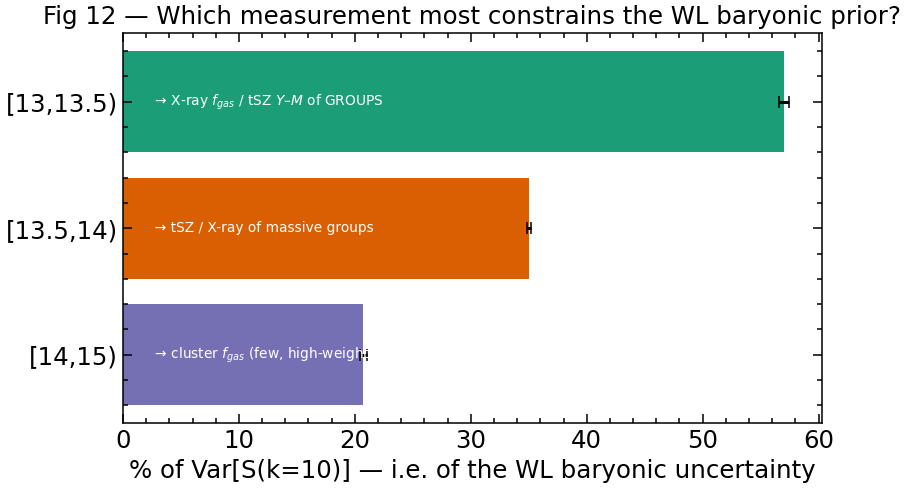

In [13]:
# ── Fig 10: synthesis — turning variance shares into an observational target ─
ik = kidx(10.0)
bs = boot_shares(ik)
mass_b = bs.reshape(-1, 3, 3).sum(2)
order = np.argsort(-mass_b.mean(0))
fig, ax = plt.subplots(figsize=(8.2, 4.6))
y = np.arange(3)
ax.barh(y, 100*mass_b.mean(0)[order], xerr=100*mass_b.std(0)[order],
        color=[MASS_C[o] for o in order], capsize=4)
probe = {"[13,13.5)": "X-ray $f_{gas}$ / tSZ $Y$–$M$ of GROUPS",
         "[13.5,14)": "tSZ / X-ray of massive groups",
         "[14,15)": "cluster $f_{gas}$ (few, high-weight)"}
for i, o in enumerate(order):
    ax.text(2, y[i], f"  → {probe[mass_labels[o]]}", va="center", fontsize=9, color="white")
ax.set_yticks(y); ax.set_yticklabels([mass_labels[o] for o in order])
ax.invert_yaxis()
ax.set_xlabel("% of Var[S(k=10)] — i.e. of the WL baryonic uncertainty")
ax.set_title("Fig 12 — Which measurement most constrains the WL baryonic prior?"
             + ("  [PROTOTYPE]" if IS_PROTO else ""))
fig.savefig(FIG / "pk_decomp_fig12_synthesis.png"); plt.show()


## 5. Robustness — anticipating the referee

| Objection | Our answer | Evidence |
|---|---|---|
| "Cosmic variance / noise, not signal." | **Common random numbers**: same halos, same ICs, same generator noise across all 256 designs — differences are pure feedback response. The design-to-design scatter (Fig 1B) is many× any noise floor. | Fig 1 |
| "Your emulator is wrong for $P(k)$." | Composite reproduces the independent box pipeline exactly; BIND@fiducial matches hydro truth; truth is a typical BIND member; per-halo fidelity in `scaling_relations.ipynb`. | Fig 2 |
| "Partial $S(k)$ is ill-defined." | Bracketed by subset-only (over) and leave-one-out (under); the Shapley midpoint is additive ($\sum_s c_s\approx\Delta S_{\rm full}$, slope $\approx$1) across scale. | Fig 4 |
| "It's just mass." | Gas terciles are taken **at fixed mass**; the gas axis carries comparable/greater share than the mass axis, and gas-rich swings most. | Figs 5,6,9 |
| "You varied one knob; the space is 30-D." | $\sim$4 params carry the response; we map all 30 → halo populations and show the decomposition is invariant along the feedback-strength axis (weak→strong). | Figs 8,10 |
| "The fiducial looks like max suppression." | It is the 8th-pct *strong*-feedback tail; more- and less-suppressed designs bracket it. The attribution is over the whole prior. | Fig 1C |
| "Overfit / too few designs." | All shares bootstrapped over designs with 16–84% CIs; stable across $k$. Prototype $=32$ designs; the pipeline auto-upgrades to the full 256. | Figs 5–7 |
| "Is the gas result just per-halo sensitivity?" | No — per-halo swing is uncorrelated with gas; the excess is a group-scale reservoir/magnitude effect, made explicit. | Fig 11 |
| "So what?" | Variance attribution → the observable (group $f_{\rm gas}$) that most tightly constrains the WL baryonic prior. | Fig 12 |

### Reproducibility
- Engine: `tools/partial_supp_sobol.py` (subset-only + leave-one-out partial $S(k)$;
  reuses `sobol_ss_cv/maps/`, CPU-only, no re-emulation).
- Full campaign: `N_CHUNKS=16 sbatch --array=0-15 run_partial_supp.sh` →
  `python tools/partial_supp_sobol.py --reduce` (writes `partial_supp_sobol.npz`);
  re-run this notebook to upgrade every number from the 32-design prototype.
- Figure module: `tools/fig_partial_supp.py`. Branch: `analysis/pk-decomposition`.
